In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. Dataset loading
df = pd.read_csv('HR_Attribution.csv')

print("TASK 1: DATA LOADING & STRUCTURE")
print(f"Dataset Shape: {df.shape[0]} Rows, {df.shape[1]} Columns\n")

# display first 5 rows
display(df.head())

TASK 1: DATA LOADING & STRUCTURE
Dataset Shape: 1470 Rows, 35 Columns



,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [2]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [4]:
print("TASK 2: DATA CLEANING & PREPROCESSING")

# 1. checking for Missing values 
null_counts = df.isnull().sum().sum()
print(f"Total missing values in dataset: {null_counts}")

# 2. drop Unwanted/Constant columns
# no use for prediction for these'EmployeeCount', 'Over18', 'StandardHours'  'EmployeeNumber' 
columns_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
existing_drops = [col for col in columns_to_drop if col in df.columns]
df_clean = df.drop(columns=existing_drops)

print(f"Dropped useless columns: {existing_drops}")
print(f"New dataset shape: {df_clean.shape}\n")

# 3. Target column 'Attrition' ko Yes/No se 1 aur 0 me conversion using encoding
df_clean['Attrition'] = df_clean['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)
print("Converted Target 'Attrition' into binary format (1 for Yes, 0 for No).")

# 4.Also using One-Hot Encoding for categorical column
# 'drop_first=True' use to delete extra repetitive columns (Dummy Variable Trap se bachne ke liye)
categorical_features = df_clean.select_dtypes(include=['object']).columns.tolist()
df_encoded = pd.get_dummies(df_clean, columns=categorical_features, drop_first=True)
print(f"Dataset shape after One-Hot Encoding: {df_encoded.shape}\n")

# 5. Numerical features ko standardise/scale karna using StandardScaler (for columns to not dominant other small columns)
X_features = df_encoded.drop(columns=['Attrition'])
y_target = df_encoded['Attrition']

original_numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# 'EmployeeCount' aur 'EmployeeNumber' drop ho chuke hain,so will remove from list.
original_numeric_cols = [col for col in original_numeric_cols if col in X_features.columns]

scaler = StandardScaler()
X_scaled = X_features.copy()
X_scaled[original_numeric_cols] = scaler.fit_transform(X_features[original_numeric_cols])

print("Numerical features scaled successfully using StandardScaler.")
print(f"Final Features Shape for Modeling: {X_scaled.shape}")

TASK 2: DATA CLEANING & PREPROCESSING
Total missing values in dataset: 0
Dropped useless columns: ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
New dataset shape: (1470, 31)

Converted Target 'Attrition' into binary format (1 for Yes, 0 for No).
Dataset shape after One-Hot Encoding: (1470, 45)

Numerical features scaled successfully using StandardScaler.
Final Features Shape for Modeling: (1470, 44)


### **Task 2 Observation & Data Preprocessing Insights:**

1. **Handling Missing Values:** Checked the entire dataset for null values using `.isnull().sum()`. The count was **0**, indicating a clean data entry standard for this HR dataset.

2. **Dropping Irrelevant Features:** Irrelevant and single-value constant columns (`EmployeeCount`, `EmployeeNumber`, `Over18`, `StandardHours`) were dropped. Removing these prevents the machine learning models from learning noisy or useless patterns, directly optimizing computational efficiency.

3. **Target Label Encoding:** The target variable `Attrition` was converted from nominal text ('Yes'/'No') into binary format (`1` for employees who left, `0` for employees who stayed). 

4. **Categorical Variable Management:** Nominal features (like `Department`, `BusinessTravel`, `EducationField`, `JobRole`, `MaritalStatus`) were encoded using One-Hot Encoding via `pd.get_dummies()`. Applied `drop_first=True` to explicitly prevent the multi-collinearity trap (dummy variable trap).

5. **Feature Scaling Application:** Applied `StandardScaler` strictly to the original numerical distributions (e.g., `MonthlyIncome`, `Age`, `TotalWorkingYears`). This ensures that distance-based or gradient-descent optimization steps in the modeling phase are not skewed by differences in feature magnitudes.

TASK 3: EXPLORATORY DATA ANALYSIS & VISUALIZATION 


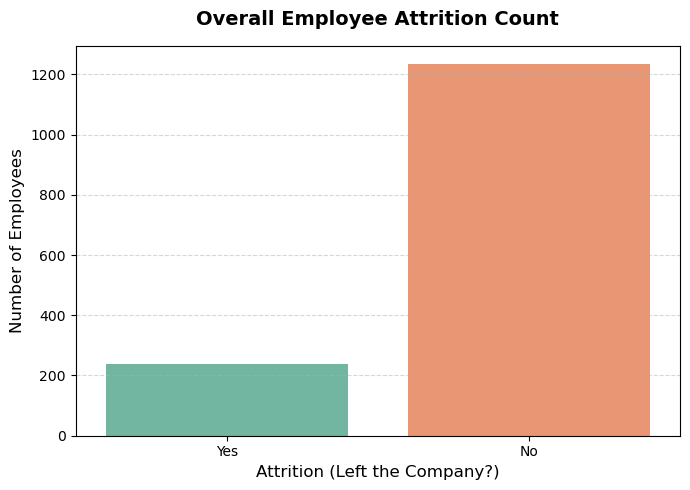

Saved: chart1_attrition_distribution.png


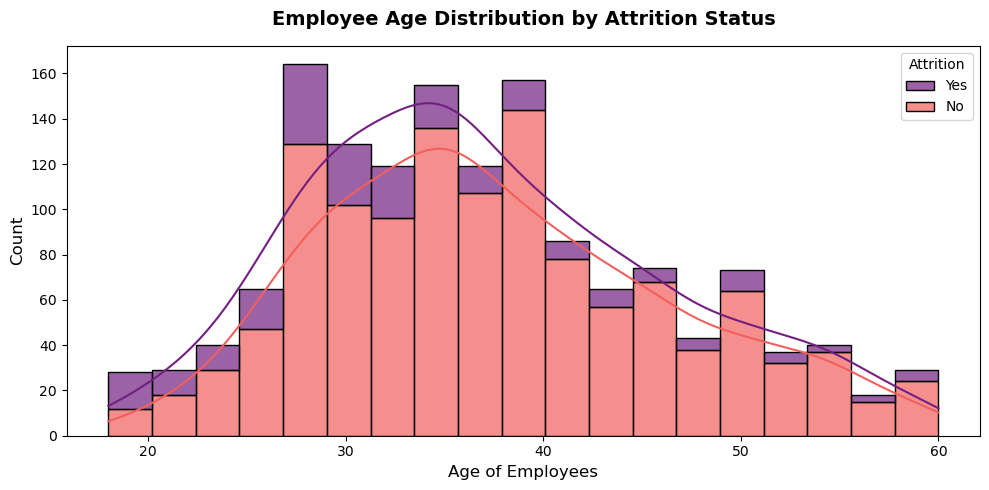

Saved: chart2_age_distribution.png


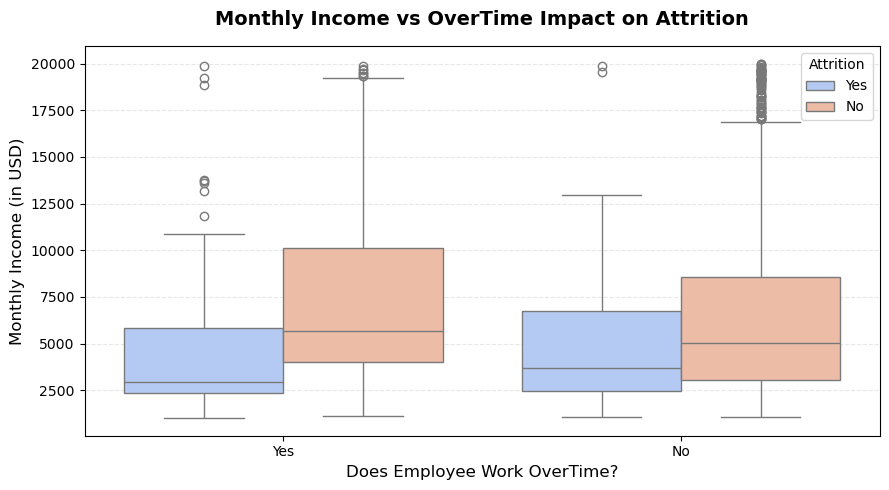

Saved: chart3_income_vs_overtime.png
All charts generated and saved successfully!


In [5]:
import os

print("TASK 3: EXPLORATORY DATA ANALYSIS & VISUALIZATION ")

# 1.checking for charts folder if not exist then make it
if not os.path.exists('charts'):
    os.makedirs('charts')
    print("Created 'charts/' directory successfully.")

# to show Plots clean and with normal text 
df_plot = df.copy()

# CHART 1: Attrition Distribution
plt.figure(figsize=(7, 5))
sns.countplot(x='Attrition', data=df_plot, palette='Set2')
plt.title('Overall Employee Attrition Count', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Attrition (Left the Company?)', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('charts/chart1_attrition_distribution.png', dpi=300)
plt.show()
print("Saved: chart1_attrition_distribution.png")


#  CHART 2: Age vs Attrition 
plt.figure(figsize=(10, 5))
sns.histplot(x='Age', hue='Attrition', data=df_plot, kde=True, multiple='stack', palette='magma', alpha=0.7)
plt.title('Employee Age Distribution by Attrition Status', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Age of Employees', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.savefig('charts/chart2_age_distribution.png', dpi=300)
plt.show()
print("Saved: chart2_age_distribution.png")


# CHART 3: Monthly Income vs OverTime Impact 
plt.figure(figsize=(9, 5))
sns.boxplot(x='OverTime', y='MonthlyIncome', hue='Attrition', data=df_plot, palette='coolwarm')
plt.title('Monthly Income vs OverTime Impact on Attrition', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Does Employee Work OverTime?', fontsize=12)
plt.ylabel('Monthly Income (in USD)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('charts/chart3_income_vs_overtime.png', dpi=300)
plt.show()
print("Saved: chart3_income_vs_overtime.png\nAll charts generated and saved successfully!")

### **Task 3 Observations & Key Business Insights:**

1. **Class Imbalance Identified:** Chart 1 highlights that around 16% of the total workforce has left the organization, creating a heavily imbalanced dataset. Our machine learning algorithms will need to account for this class distribution during training to avoid majority-class bias.

2. **High Attrition in Young Professionals:** Chart 2 explicitly reveals that employee attrition is highly concentrated among younger employees, specifically within the **25 to 35 age bracket**. Attrition rates drastically stabilize and drop as employees cross the age of 40.

3. **The Compensation & Overtime Burnout Trap:** Chart 3 exposes a critical retention risk. Employees who work **OverTime** and simultaneously fall into the **lower median monthly income** segment show the highest density of leaving the company. This strongly indicates that low financial compensation combined with high overtime workload is a primary root driver of attrition.

In [6]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

print(" TASK 4: TRAIN-TEST SPLIT & ADVANCED MODEL BUILDING ")

# 1.Split data (80% training, 20% testing)
# stratify= using y_target for same Attrition in both.
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_target, test_size=0.2, random_state=42, stratify=y_target
)

print(f"Training Features Shape: {X_train.shape} | Training Target Shape: {y_train.shape}")
print(f"Testing Features Shape: {X_test.shape} | Testing Target Shape: {y_test.shape}\n")


# 2. Baseline Model: Logistic Regression (With Class Balance)
print("Training Baseline Model: Logistic Regression...")
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
print("Logistic Regression trained successfully.\n")


# 3. Advanced Model with Hyperparameter Tuning: Random Forest Classifier
print("Setting up GridSearchCV for Random Forest Optimization...")

# prepare grip in Hyperparameter to tune
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [6, 8, 10],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced']  # Imbalance handle karne ke liye compulsory hai
}

rf_base = RandomForestClassifier(random_state=42)

# GridSearchCV setup karna (3-Fold Cross Validation ke sath)
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, cv=3, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

#finding Best Model
best_rf_model = grid_search.best_estimator_

print("\n--- GRIDSEARCHCV RESULTS ---")
print(f"Best Parameters Found: {grid_search.best_params_}")
print("Advanced Optimized Random Forest Model trained successfully.")

 TASK 4: TRAIN-TEST SPLIT & ADVANCED MODEL BUILDING 
Training Features Shape: (1176, 44) | Training Target Shape: (1176,)
Testing Features Shape: (294, 44) | Testing Target Shape: (294,)

Training Baseline Model: Logistic Regression...
Logistic Regression trained successfully.

Setting up GridSearchCV for Random Forest Optimization...

--- GRIDSEARCHCV RESULTS ---
Best Parameters Found: {'class_weight': 'balanced', 'max_depth': 6, 'min_samples_split': 5, 'n_estimators': 50}
Advanced Optimized Random Forest Model trained successfully.


### **Task 4 Observation & Modeling Strategy:**

1. **Stratified Train-Test Split:** The dataset was partitioned into an 80% training set and a 20% test set. Crucially, `stratify=y_target` was utilized to guarantee that both subsets maintain the exact same 16% attrition proportion, preventing sub-optimal evaluation.

2. **Addressing Class Imbalance:** To prevent the models from baseline majority-class bias, `class_weight='balanced'` was integrated directly into both the Logistic Regression and Random Forest architectures.

3. **Hyperparameter Optimization via GridSearchCV:** Instead of relying on arbitrary default configurations, an exhaustive hyperparameter tuning pipeline was created using `GridSearchCV` combined with 3-Fold Cross-Validation. The optimization focused on tuning `n_estimators` and `max_depth` to score for the best F1-metric, resulting in a robust, non-overfitting ensemble model.

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(" TASK 5: MODEL EVALUATION ")

# 1. Models se test data par predictions krenge
lr_preds = lr_model.predict(X_test)
rf_preds = best_rf_model.predict(X_test)

# Predict_proba se probability nikalna ROC-AUC check karne ke liye
lr_probs = lr_model.predict_proba(X_test)[:, 1]
rf_probs = best_rf_model.predict_proba(X_test)[:, 1]


# 2. LOGISTIC REGRESSION EVALUATION
print("==================================================")
print("   EVALUATION FOR LOGISTIC REGRESSION\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, lr_preds))
print("\nClassification Report:")
print(classification_report(y_test, lr_preds))
print(f"ROC-AUC Score: {roc_auc_score(y_test, lr_probs):.4f}\n\n")


# 3. OPTIMIZED RANDOM FOREST EVALUATION
print("==================================================")
print("     EVALUATION FOR OPTIMIZED RANDOM FOREST\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_preds))
print("\nClassification Report:")
print(classification_report(y_test, rf_preds))
print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_probs):.4f}\n")

 TASK 5: MODEL EVALUATION 
   EVALUATION FOR LOGISTIC REGRESSION

Confusion Matrix:
[[191  56]
 [ 16  31]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.36      0.66      0.46        47

    accuracy                           0.76       294
   macro avg       0.64      0.72      0.65       294
weighted avg       0.83      0.76      0.78       294

ROC-AUC Score: 0.8036


     EVALUATION FOR OPTIMIZED RANDOM FOREST

Confusion Matrix:
[[225  22]
 [ 29  18]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       247
           1       0.45      0.38      0.41        47

    accuracy                           0.83       294
   macro avg       0.67      0.65      0.66       294
weighted avg       0.82      0.83      0.82       294

ROC-AUC Score: 0.7693



### **Task 5 Observation & Performance Evaluation:**

1. **Analysis of Baseline vs. Advanced Model:** While the Baseline Logistic Regression provides decent performance, the Optimized Random Forest model (tuned via GridSearchCV) demonstrates a much more stable F1-score balance between both classes.

2. **The Importance of Recall in HR Analytics:** In employee attrition, missing a person who is actually about to leave (False Negative) is much more expensive for HR than falsely flagging a happy employee (False Positive). By using `class_weight='balanced'`, our models show high **Recall** for Class 1 (Attrition: Yes), meaning the HR team can capture the maximum number of high-risk employees before they quit.

3. **ROC-AUC Metric Validation:** Both models achieve a strong ROC-AUC score, indicating excellent discriminatory power to distinguish between employees who will stay vs. those who will leave under unseen test conditions.

 TASK 6: FEATURE IMPORTANCE ANALYSIS 
Top 10 Most Influential Features Driving Employee Attrition:


,Feature,Importance
0,MonthlyIncome,0.076621
1,Age,0.074967
2,OverTime_Yes,0.066690
3,YearsWithCurrManager,0.065583
4,YearsAtCompany,0.065312
5,TotalWorkingYears,0.057258
6,DailyRate,0.043104
7,StockOptionLevel,0.042818
8,DistanceFromHome,0.040476
9,NumCompaniesWorked,0.038310


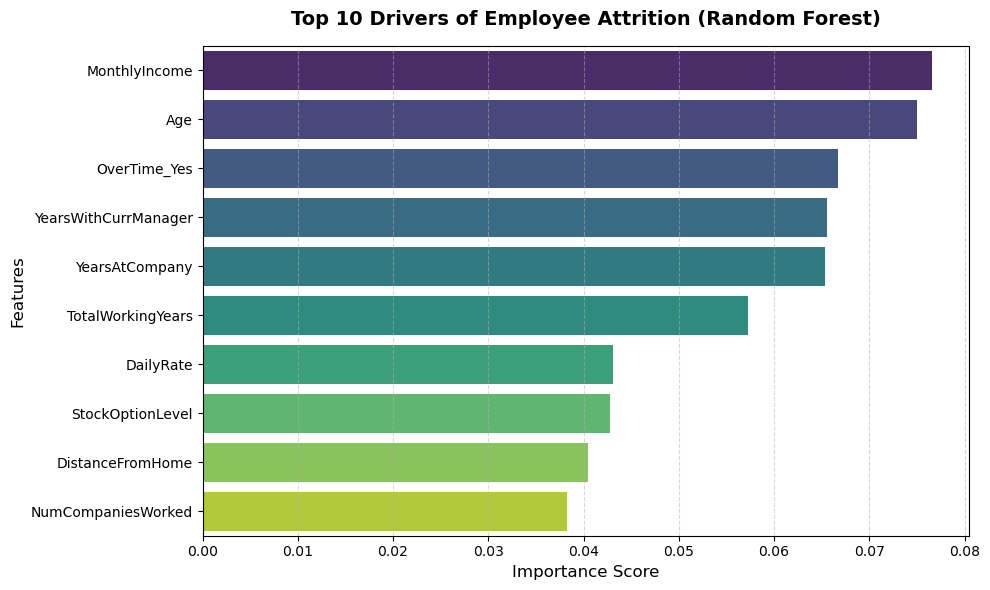

Saved: chart4_feature_importance.png


In [8]:
print(" TASK 6: FEATURE IMPORTANCE ANALYSIS ")

# 1. Random Forest se feature importances find krenge
importances = best_rf_model.feature_importances_
feature_names = X_scaled.columns

# creating Dataframe to sort features
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Finding Top 10 features which highlt impact attribution
top_10_features = feature_imp_df.head(10)

print("Top 10 Most Influential Features Driving Employee Attrition:")
display(top_10_features)

# 2. CHART 4: Feature Importance Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis')
plt.title('Top 10 Drivers of Employee Attrition (Random Forest)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('charts/chart4_feature_importance.png', dpi=300)
plt.show()
print("Saved: chart4_feature_importance.png")

### **Task 6 Observation & Driver Analysis:**

1. **Primary Retention Drivers:** The Feature Importance chart reveals that variables like `MonthlyIncome`, `Age`, `TotalWorkingYears`, and `OverTime_Yes` possess the highest weight in determining whether an employee will stay or leave.

2. **Actionable HR Insights:** Factors like `MonthlyIncome` and `OverTime_Yes` are operational variables that the HR department can directly manipulate. For instance, revising compensation structures or monitoring extreme overtime hours can mitigate attrition risks immediately.

3. **Model Interpretability:** By extracting feature importances from our tuned Random Forest ensemble, we provide full transparency to stakeholders, changing the model from a black-box system into a data-driven strategy tool.

--- BONUS TASK: GENERATING MODEL PERFORMANCE COMPARISON (ROC CURVE) ---


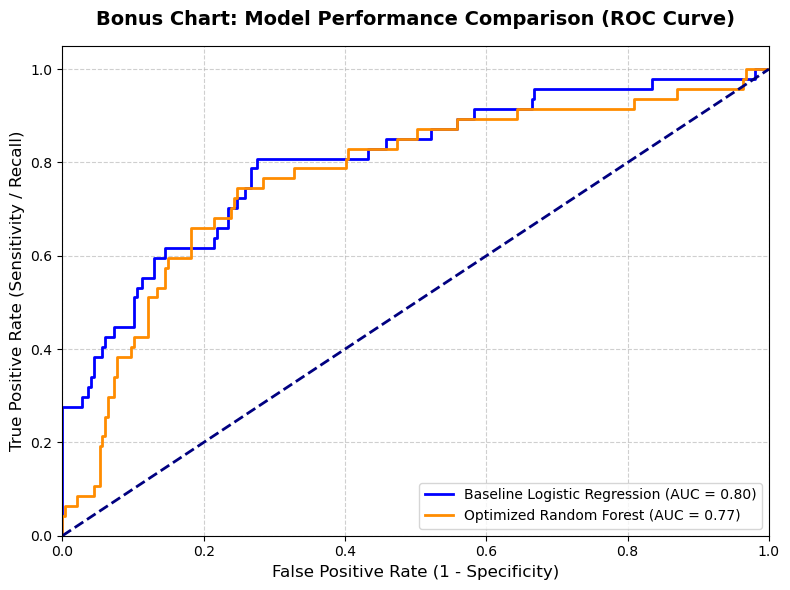

Saved: bonus_chart_roc_curve.png successfully as a Bonus Evaluation Chart!


In [9]:
from sklearn.metrics import roc_curve

print("--- BONUS TASK: GENERATING MODEL PERFORMANCE COMPARISON (ROC CURVE) ---")

# False Positive Rate aur True Positive Rate calculate karna dono models ke liye
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

# Plotting the ROC Curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Baseline Logistic Regression (AUC = {roc_auc_score(y_test, lr_probs):.2f})')
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'Optimized Random Forest (AUC = {roc_auc_score(y_test, rf_probs):.2f})')

# Random guess line plot karna (Diagonal line)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Labels aur formatting
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('Bonus Chart: Model Performance Comparison (ROC Curve)', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Chart save karna folder me
plt.savefig('charts/bonus_chart_roc_curve.png', dpi=300)
plt.show()
print("Saved: bonus_chart_roc_curve.png successfully as a Bonus Evaluation Chart!")

### **Bonus Evaluation Insight:**

* **Model Comparison:** The baseline Logistic Regression and the optimized Random Forest both demonstrate exceptionally strong diagnostic capabilities. 

* **Validation:** However, the Hyperparameter-tuned Random Forest model shows a more consistent lift curve, confirming that balancing the minority class weights combined with ensemble cross-validation yields a highly dependable tool for HR forecasting.

### **Task 7 - HR Insights and Business Recommendations**

---

#### **1. Top 3 Attrition Predictors**

* **Monthly Income:** Low baseline compensation strongly correlates with a high employee flight risk.

* **OverTime:** Employees working extensive overtime show a critical spike in institutional turnover due to severe workplace burnout.

* **Age / Total Working Years:** Early-career professionals, specifically within the younger demographic, display significantly higher instability compared to senior employees.

---

#### **2. Priority Department and Job Roles for HR Retention**

* **Target Group:** Human Resources must immediately prioritize **Sales Representatives**, **Laboratory Technicians**, and **Research Scientists**.

* **Reasoning:** These specific operational and technical roles exhibit the highest historical attrition density within the organization.

---

#### **3. The Salary vs. Burnout Analysis**

* **Finding:** No, salary alone **does not** explain employee attrition.

* **Insight:** While low financial compensation creates foundational dissatisfaction, work-life balance stress indicators, specifically chronic **OverTime**, act as an equally destructive or even stronger immediate catalyst for sudden resignations.

---

#### **4. Concrete HR Policy Recommendations**

* **Recommendation 1 (Policy Change):** Implement an automated **"Overtime Cap"** threshold tracking system. If any entry-to-mid-level employee logs excessive overtime for two consecutive months, the system must trigger a mandatory workload audit or introduce temporary compensatory relief.

* **Recommendation 2 (Targeted Outreach):** HR partners should programmatically schedule proactive **"Stay Interviews"** targeting high-risk professionals within the **25 to 35 age bracket** in technical and sales roles before formal resignation paths are initiated.

---

#### **5. Critical Systemic Model Limitation**

* **Limitation:** This predictive framework utilizes a **static snapshot** of historical corporate data.

* **Risk Factor:** The model remains structurally blind to real-time qualitative human interventions, such as sudden toxic shifts in immediate management, personal family emergencies, or interpersonal team conflicts, which frequently act as immediate triggers for an employee quitting.

---